# Basic Data Visualization 
In today's lecture, we will introduce basic data visualization. This is another important way to understand your data is to visualize it. Later in this course, we will spend loads of time talking about best practices for data visualization. Today, we're going to introduce a few core concepts. 

First thing, let's load our libraries then load the data set we'd like to visualize. 

In [4]:
# load libraries
library(dplyr)
library(ggplot2)

# load data
df <- ggplot2::mpg
glimpse(df)



Attaching package: ‘dplyr’




The following objects are masked from ‘package:stats’:

    filter, lag




The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




Rows: 234
Columns: 11
$ manufacturer <chr> "audi", "audi", "audi", "audi", "audi", "audi", "audi", "…
$ model        <chr> "a4", "a4", "a4", "a4", "a4", "a4", "a4", "a4 quattro", "…
$ displ        <dbl> 1.8, 1.8, 2.0, 2.0, 2.8, 2.8, 3.1, 1.8, 1.8, 2.0, 2.0, 2.…
$ year         <int> 1999, 1999, 2008, 2008, 1999, 1999, 2008, 1999, 1999, 200…
$ cyl          <int> 4, 4, 4, 4, 6, 6, 6, 4, 4, 4, 4, 6, 6, 6, 6, 6, 6, 8, 8, …
$ trans        <chr> "auto(l5)", "manual(m5)", "manual(m6)", "auto(av)", "auto…
$ drv          <chr> "f", "f", "f", "f", "f", "f", "f", "4", "4", "4", "4", "4…
$ cty          <int> 18, 21, 20, 21, 16, 18, 18, 18, 16, 20, 19, 15, 17, 17, 1…
$ hwy          <int> 29, 29, 31, 30, 26, 26, 27, 26, 25, 28, 27, 25, 25, 25, 2…
$ fl           <chr> "p", "p", "p", "p", "p", "p", "p", "p", "p", "p", "p", "p…
$ class        <chr> "compact", "compact", "compact", "compact", "compact", "c…


# Revisiting data cleaning

Before we make our plots, let's do some data cleaning again. Remember that the variables you do or don't need should be informed by your research question or objective.

In [5]:
# let's look at what manufacturer's are in this dataset by treating the manufacturer column as a factor
summary(as.factor(df$manufacturer))

audi  chevrolet      dodge       ford      honda    hyundai       jeep 
        18         19         37         25          9         14          8 
land rover    lincoln    mercury     nissan    pontiac     subaru     toyota 
         4          3          4         13          5         14         34 
volkswagen 
        27

In [6]:
# -------------------------------------------------------------------------
# clean data:
# -------------------------------------------------------------------------
# our research Q is:
# - only interested in Ford, dodge and toyota
# - not about the type of fuel "fl"
df_clean <- df %>%
    filter(manufacturer== "ford" | manufacturer== "dodge" | manufacturer== "toyota") %>%
    select(-fl) %>%
    mutate(cyl = as.factor(cyl)) # data manipulation: factor datatypes are discrete categories

glimpse(df_clean)

Rows: 96
Columns: 10
$ manufacturer <chr> "dodge", "dodge", "dodge", "dodge", "dodge", "dodge", "do…
$ model        <chr> "caravan 2wd", "caravan 2wd", "caravan 2wd", "caravan 2wd…
$ displ        <dbl> 2.4, 3.0, 3.3, 3.3, 3.3, 3.3, 3.3, 3.8, 3.8, 3.8, 4.0, 3.…
$ year         <int> 1999, 1999, 1999, 1999, 2008, 2008, 2008, 1999, 1999, 200…
$ cyl          <fct> 4, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 8, 8, 8, 8, …
$ trans        <chr> "auto(l3)", "auto(l4)", "auto(l4)", "auto(l4)", "auto(l4)…
$ drv          <chr> "f", "f", "f", "f", "f", "f", "f", "f", "f", "f", "f", "4…
$ cty          <int> 18, 17, 16, 16, 17, 17, 11, 15, 15, 16, 16, 15, 14, 13, 1…
$ hwy          <int> 24, 24, 22, 22, 24, 24, 17, 22, 21, 23, 23, 19, 18, 17, 1…
$ class        <chr> "minivan", "minivan", "minivan", "minivan", "minivan", "m…


# Plotting
Let's go through the following plots 
- histogram 
- box plot
- bar
- scatter (point)
- color as a third dimension 
- facet wrapping 

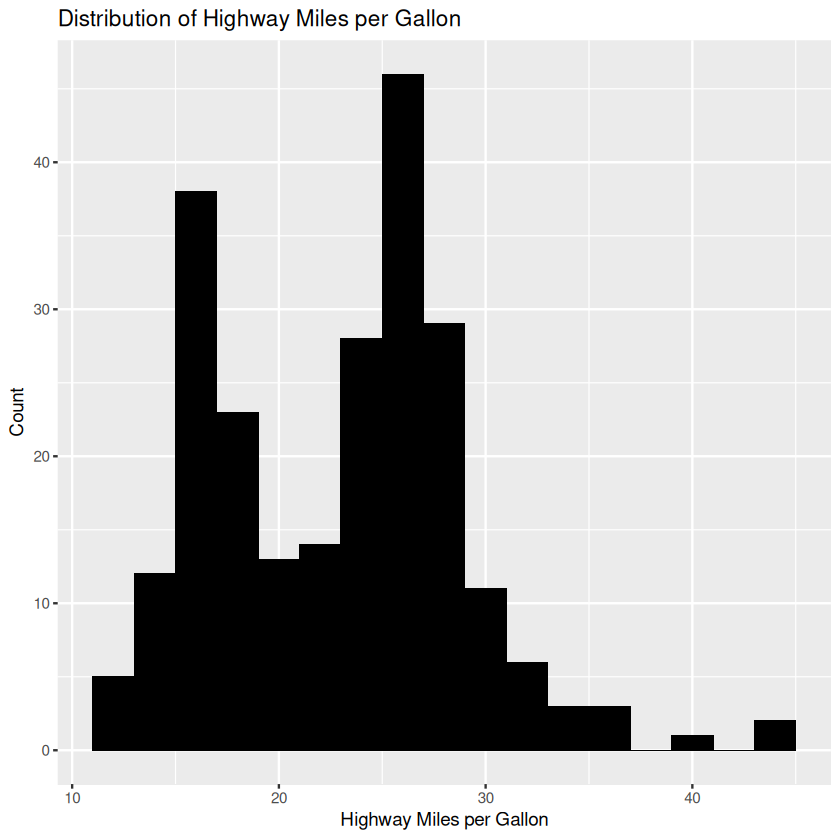

In [8]:
# -------------------------------------------------------------------------
# Histogram -- the distribution of a single numerical variable: geom_histogram()
# -------------------------------------------------------------------------
#AC: run these one line at a time 
#   - aes: aesthetics 
#   - tells you the axis you'll be plotting
#       - x axis: hwy mpg

# dataframe is an input to the plot function
ggplot(df, aes(x = hwy)) +
    # geom_histogram() +
    geom_histogram(binwidth = 2, fill = "black") + # inputs change look
    labs(title = "Distribution of Highway Miles per Gallon",
             x = "Highway Miles per Gallon",
             y = "Count")


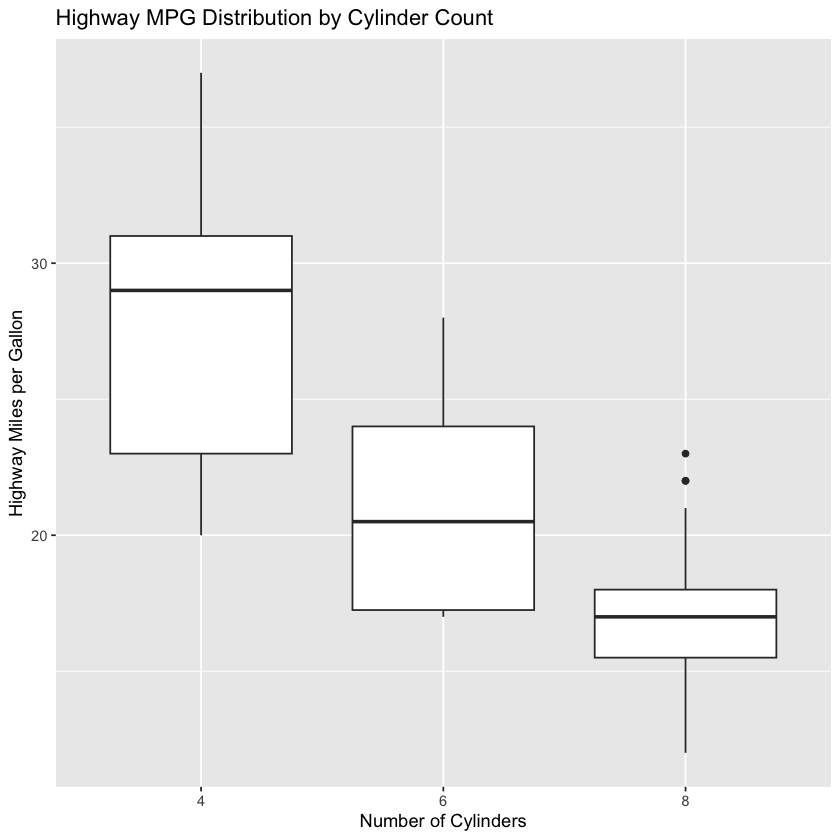

In [5]:
# -------------------------------------------------------------------------
# Box plot -- continuous variable for different categories: geom_boxplot()
# cyl: number of cylinders
# -------------------------------------------------------------------------
df_clean %>% # Pipe data
    ggplot(aes(x = cyl, y = hwy)) + # make the plot
    geom_boxplot() +
    labs(title = "Highway MPG Distribution by Cylinder Count",
         x = "Number of Cylinders",
         y = "Highway Miles per Gallon")

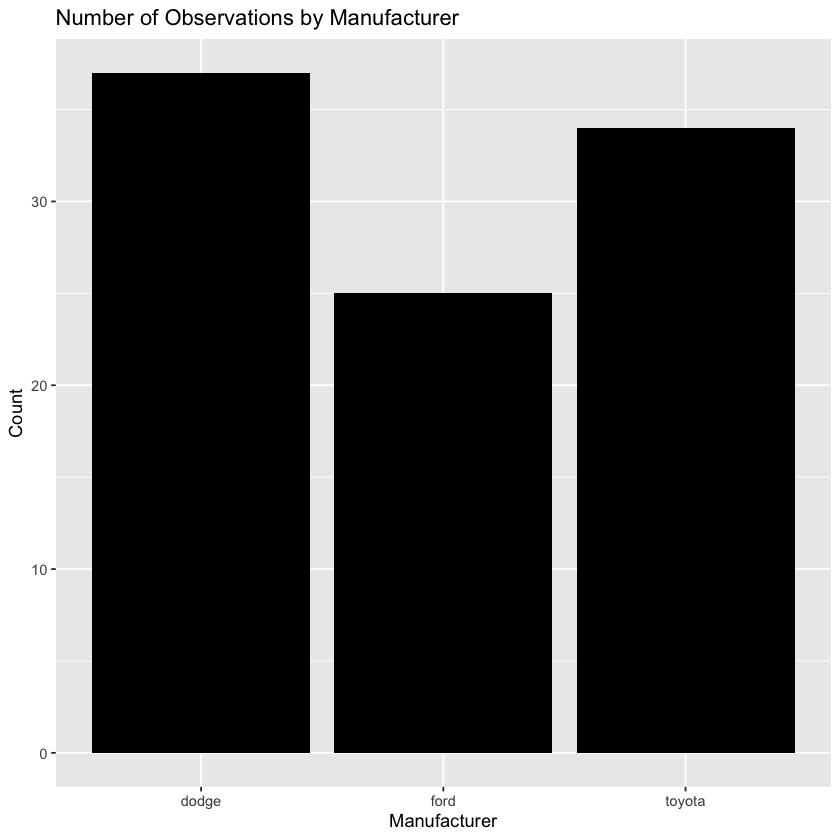

In [6]:
# -------------------------------------------------------------------------
# Bar chart -- count of observations in different categories: geom_bar()
# -------------------------------------------------------------------------
ggplot(df_clean, aes(x = manufacturer)) +
    geom_bar(fill = "black") +
    labs(title = "Number of Observations by Manufacturer",
         x = "Manufacturer",
         y = "Count")

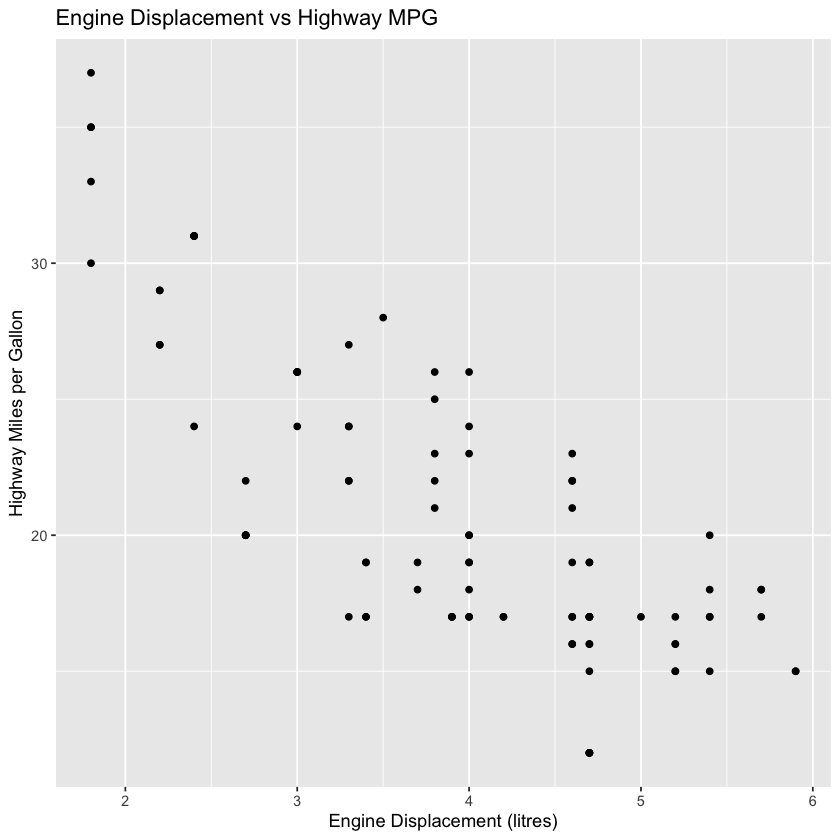

In [7]:
# -------------------------------------------------------------------------
# Scatter plot -- two continuous variables: geom_point()
# hwy: highway miles per gallon
# displ: engine displacement which is approx. engine size
# -------------------------------------------------------------------------
ggplot(df_clean, aes(x = displ, y = hwy)) +
    geom_point() +
    labs(title = "Engine Displacement vs Highway MPG",
         x = "Engine Displacement (litres)",
         y = "Highway Miles per Gallon")

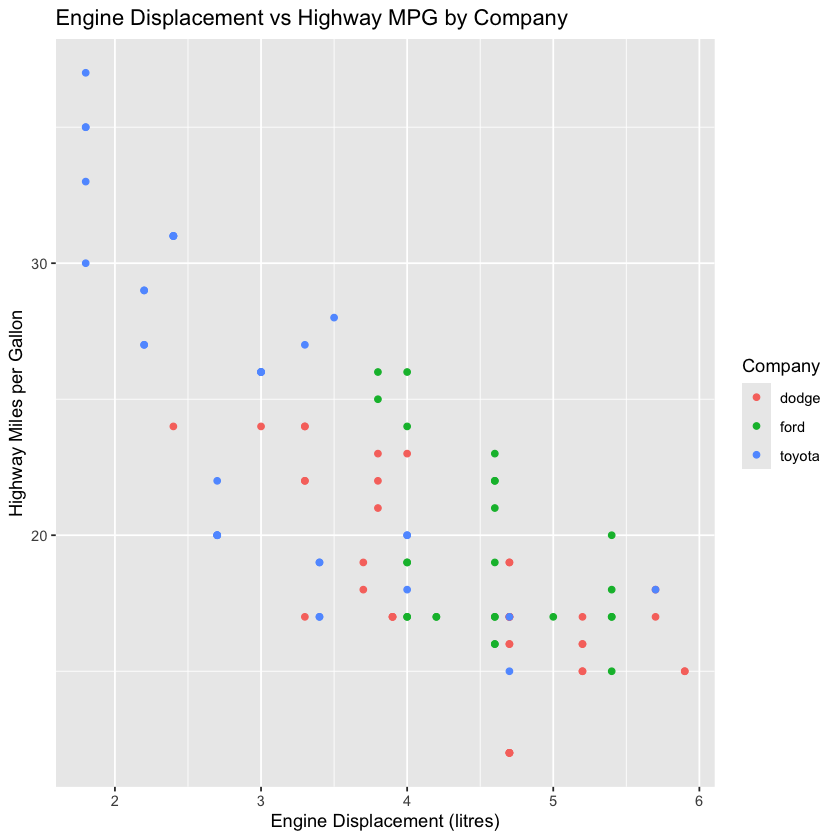

In [8]:
# Third color axis: groups that you want shown in different colors.
ggplot(df_clean, aes(x = displ, y = hwy, color = manufacturer)) +
    geom_point() +
    labs(title = "Engine Displacement vs Highway MPG by Company",
         x = "Engine Displacement (litres)",
         y = "Highway Miles per Gallon",
         color = "Company")

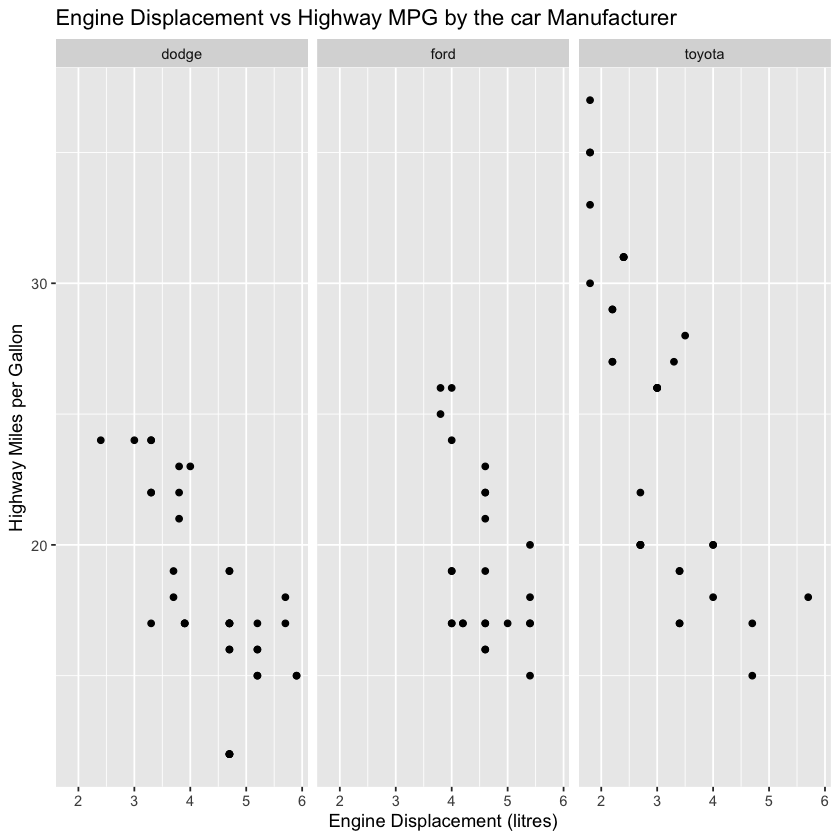

In [9]:
# -------------------------------------------------------------------------
# Multiple plots -- same graph for different categories: facet_wrap()
# - same information as the last chart with the color
# -------------------------------------------------------------------------
# can store a graph as an object
myFacet <- ggplot(df_clean, aes(x = displ, y = hwy)) +
    geom_point() + # type of graph you want to see multiple times
    facet_wrap(~manufacturer) + # separated by what?
    labs(title = "Engine Displacement vs Highway MPG by the car Manufacturer",
         x = "Engine Displacement (litres)",
         y = "Highway Miles per Gallon")
# display the graph
myFacet